# Retrieval Analysis and Jump Debugging

This notebook analyzes the effective parameters for 4 specific geometry cases to understand discontinuities ('jumps') in the results.

## Selected Points
- [0] Left 50%        | r1=0.2922, r2=0.3721
- [1] Peak Linearity  | r1=0.2537, r2=0.3616
- [2] Right 50%       | r1=0.2312, r2=0.3438
- [3] Baseline Tail   | r1=0.2179, r2=0.3153

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import meep as mp

# Setup paths
root = r"/zhome/2f/7/202918/phc_nzi"
src = r"/zhome/2f/7/202918/phc_nzi/src"
sys.path.append(root)
sys.path.append(src)

from phc_nzi.photonic_crystal_maker import (Material, BaseDielectricDistribution, PhotonicCrystal, SquareLattice)
from phc_nzi.mpb_configurator import MPBSchemeConfigurator
from phc_nzi.simulation_handler import MPBDataOptions, Simulation
from phc_nzi.field_analyzer import FieldAnalyzer

In [2]:
# Define the 4 cases
cases = [
    {"name": "Left 50%", "r1": 0.2922, "r2": 0.3721},
    {"name": "Peak Linearity", "r1": 0.2537, "r2": 0.3616},
    {"name": "Right 50%", "r1": 0.2312, "r2": 0.3438},
    {"name": "Baseline Tail", "r1": 0.2179, "r2": 0.3153}
]

# Common Parameters
T = 4
n_InP = 3.075 * (1 + 2.7e-5 * T)
eps_inp = round(n_InP**2, 2)
RESOLUTION = 32

# Lattice and K-points
lattice_2D = SquareLattice()
k_points_around_gamma = lattice_2D.get_k_points_around_gamma(distance=0.1)
# k_points_around_gamma usually returns a dict with "k_points_values" list

# Ensure data directory exists
data_root = "/work3/enrva/phc_nzi_data/MPB_data/retrieval_debug"
if not os.path.exists(data_root):
    os.makedirs(data_root)

In [8]:
def run_simulation_and_retrieve(case_idx, r1, r2, name):
    print(f"Processing Case {case_idx}: {name} (r1={r1}, r2={r2})")
    
    # 1. Setup Geometry
    geom_2D = BaseDielectricDistribution(eps_bulk=eps_inp, eps_atoms=1).make_C4v_diatomic_B()
    photonic_crystal_2D = PhotonicCrystal(lattice=lattice_2D, atoms=geom_2D)
    
    # 2. Setup Simulation Configuration
    sim_name = f"C4v_debug_case_{case_idx}_{name.replace(' ', '_')}"
    
    configuration_options = dict(
        resolution=RESOLUTION,
        num_bands=8,
        k_points=[mp.Vector3(0.1, 0), mp.Vector3(0,0)],
        k_points_interpolation_factor=100,
        extra_runner_command=(
        "fix-hfield-phase fix-efield-phase "
        "output-hfield output-nonbloch-efield-y output-nonbloch-hfield-z"
        ),
    )
    
    mpb_config = MPBSchemeConfigurator(photonic_crystal_2D, ["te"], **configuration_options)
    script = mpb_config.get_scheme_config(join_newline=True)
    
    simulation = Simulation(
        simulation_name=sim_name,
        script=script,
        directory=os.path.join(data_root, sim_name)
    )
    
    # 3. Run Simulation
    simulation.run_hpc(mpb_command_line_params={"r1": r1, "r2": r2})
    
    # 4. Retrieval
    analyzer = FieldAnalyzer(simulation, bands=[4, 5, 6], polarization="te", k_direction="x") 
    
    # Retrieve Parameters
    # IMPORTANT: Setting use_reference_mask=False triggers the new dynamic masking!
    results_df = analyzer.get_eps_mu_impedance_neff(
        component_i="y", 
        component_j="z", 
        plot=False, 
        use_reference_mask=False, 
        enforce_continuity=True
    )
    
    return analyzer, results_df


In [9]:
# Run for all cases
analyzers = []
result_dfs = []

for idx, case in enumerate(cases):
    an, df = run_simulation_and_retrieve(idx, case['r1'], case['r2'], case['name'])
    analyzers.append(an)
    result_dfs.append(df)

Processing Case 0: Left 50% (r1=0.2922, r2=0.3721)
COMMANDS ['(define-param h 1e+20)', '(define-param r1 0.1)', '(define-param r2 0.2)']
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processing item: name 'options' is not defined
Error processin

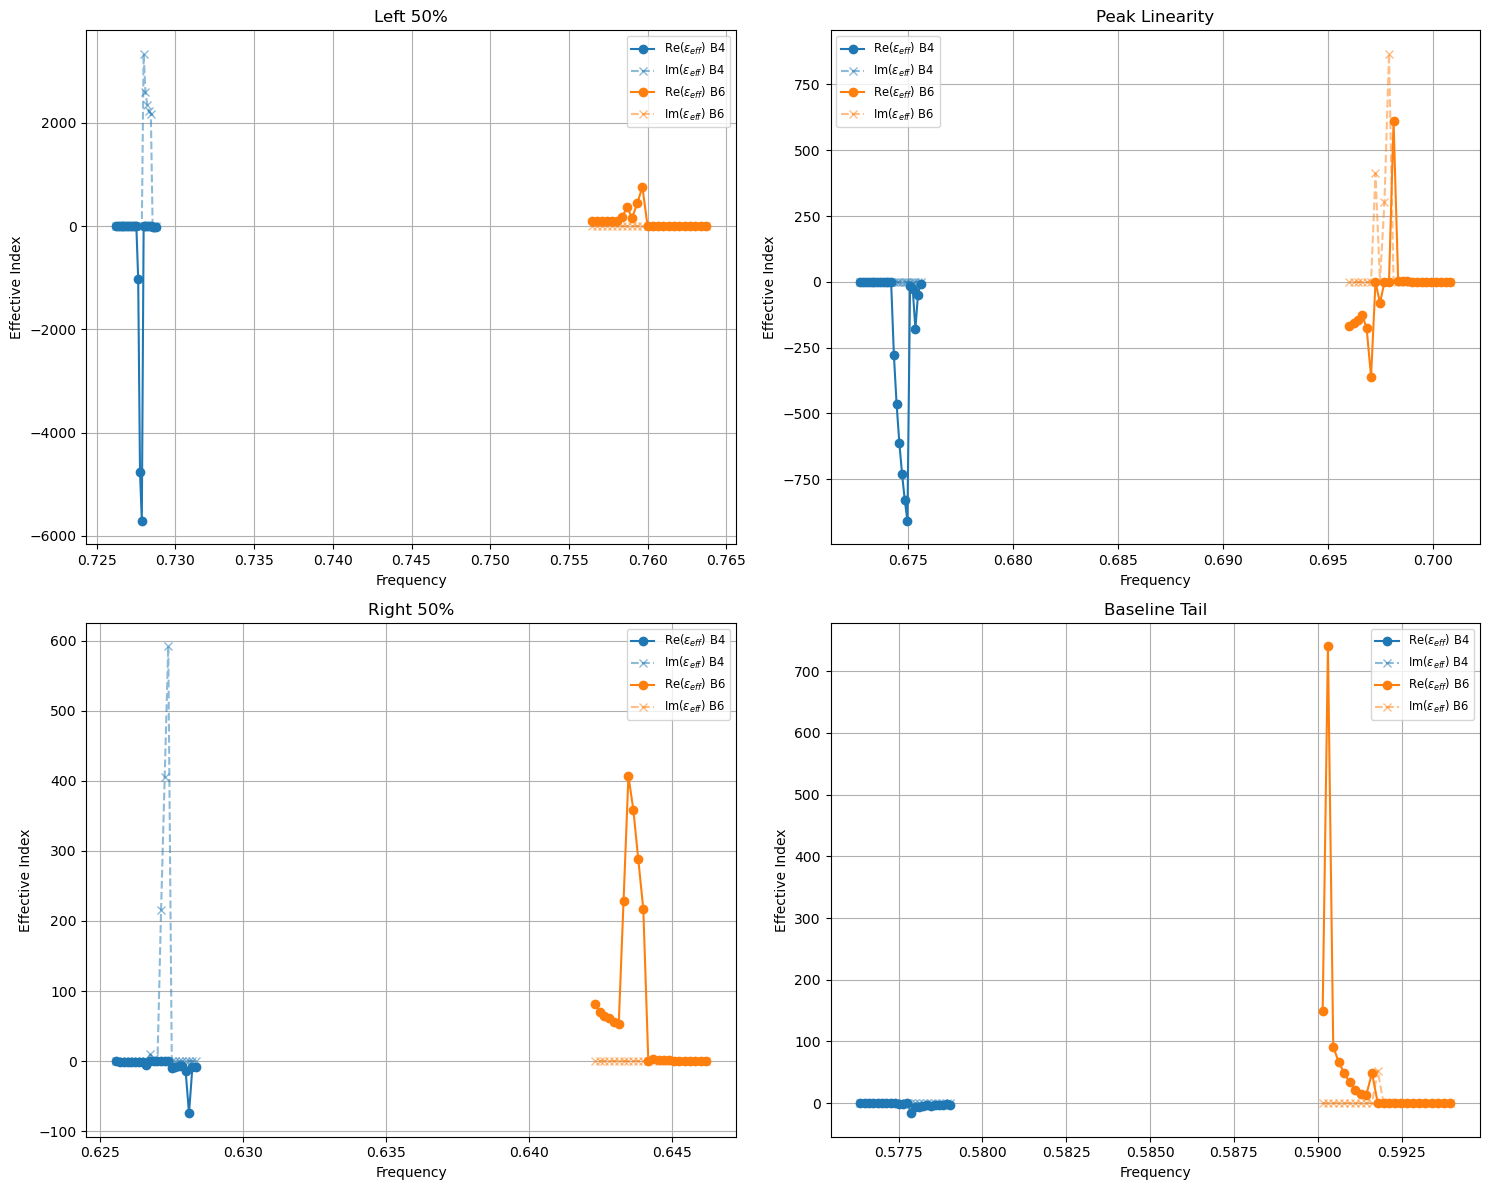

In [10]:
# Plotting and Jump Investigation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, (df, case) in enumerate(zip(result_dfs, cases)):
    ax = axes[idx]
    ax.set_title(f"{case['name']}")
    
    # Plot multiple bands to see upper/lower branches (e.g., 4, 5, 6)
    bands_to_plot = [4, 6]
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    
    for b_idx, color in zip(bands_to_plot, colors):
        df_band = df[df['band'] == b_idx]
        if not df_band.empty:
            ax.plot(df_band['frequency'], df_band['eps'].apply(lambda x: x.real), 'o-', color=color, label=rf'Re($\varepsilon_{{eff}}$) B{b_idx}')
            ax.plot(df_band['frequency'], df_band['eps'].apply(lambda x: x.imag), 'x--', color=color, alpha=0.5, label=rf'Im($\varepsilon_{{eff}}$) B{b_idx}')
    
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Effective Index")
    ax.legend(fontsize='small')
    ax.grid(True)

plt.tight_layout()
plt.show()

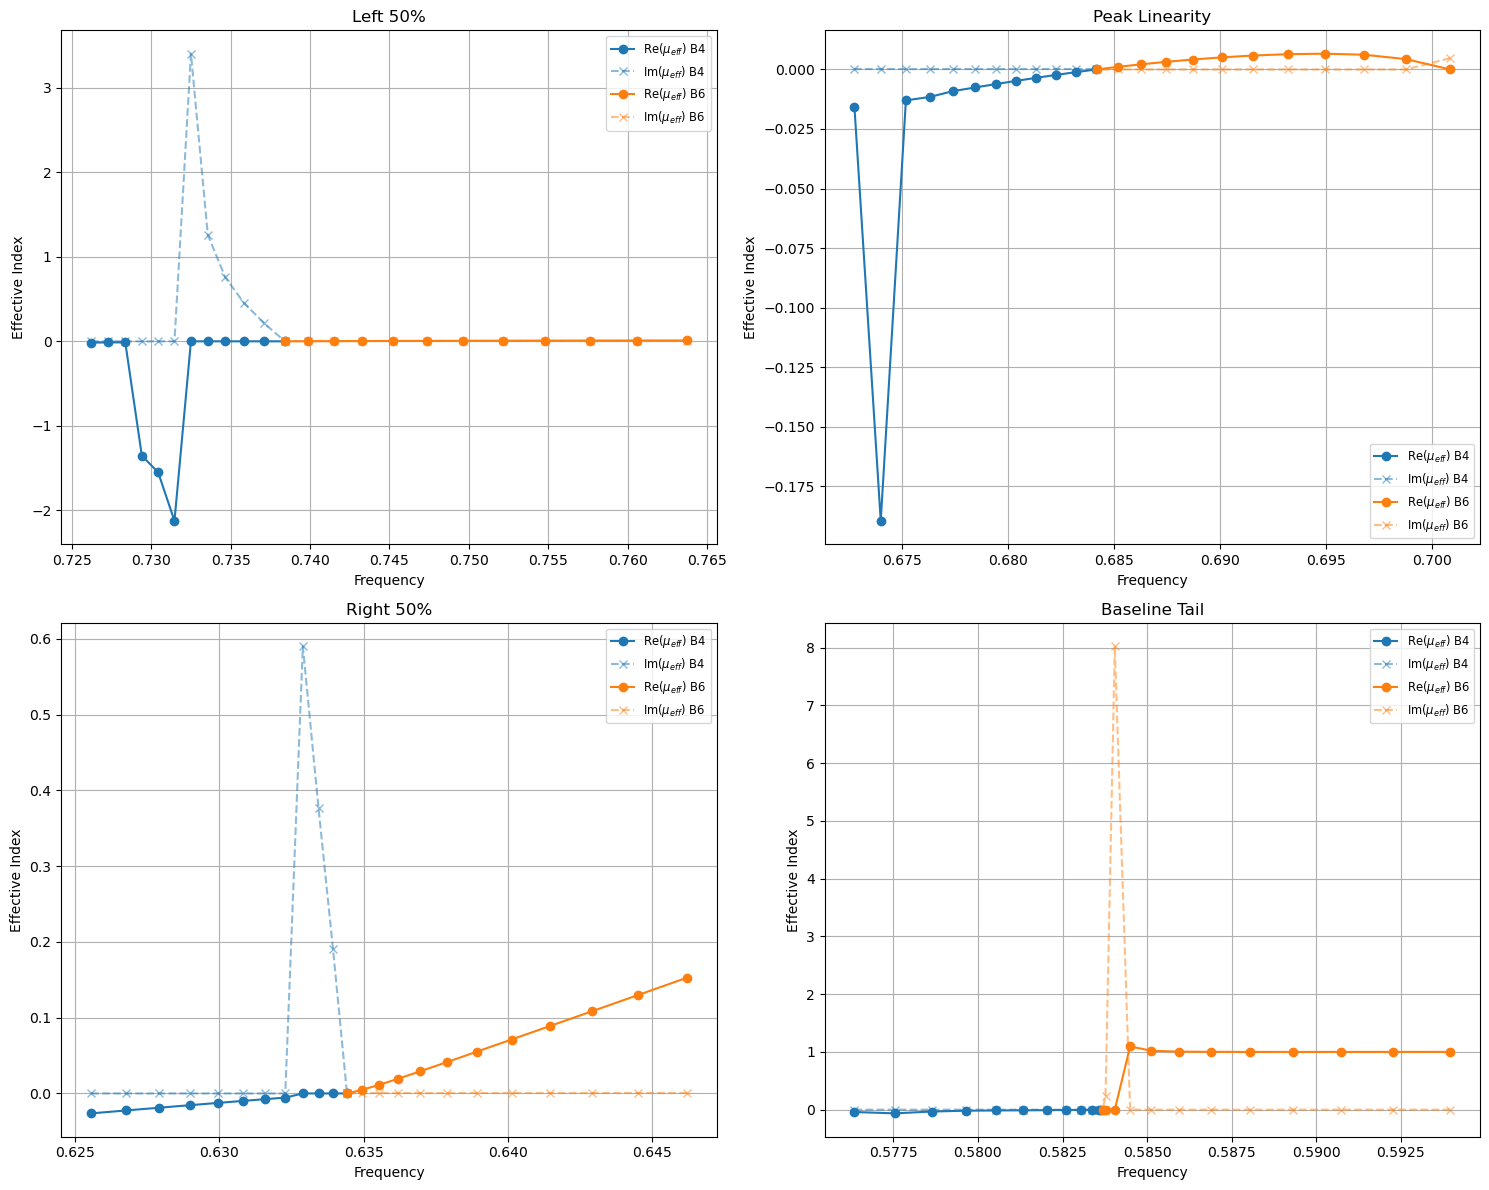

In [ ]:
# Plotting and Jump Investigation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, (df, case) in enumerate(zip(result_dfs, cases)):
    ax = axes[idx]
    ax.set_title(f"{case['name']}")
    
    # Plot multiple bands to see upper/lower branches (e.g., 4, 5, 6)
    bands_to_plot = [4, 6]
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    
    for b_idx, color in zip(bands_to_plot, colors):
        df_band = df[df['band'] == b_idx]
        if not df_band.empty:
            ax.plot(df_band['frequency'], df_band['mu'].apply(lambda x: x.real), 'o-', color=color, label=rf'Re($\mu_{{eff}}$) B{b_idx}')
            ax.plot(df_band['frequency'], df_band['mu'].apply(lambda x: x.imag), 'x--', color=color, alpha=0.5, label=rf'Im($\mu_{{eff}}$) B{b_idx}')
    
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Effective Index")
    ax.legend(fontsize='small')
    ax.grid(True)

plt.tight_layout()
plt.show()

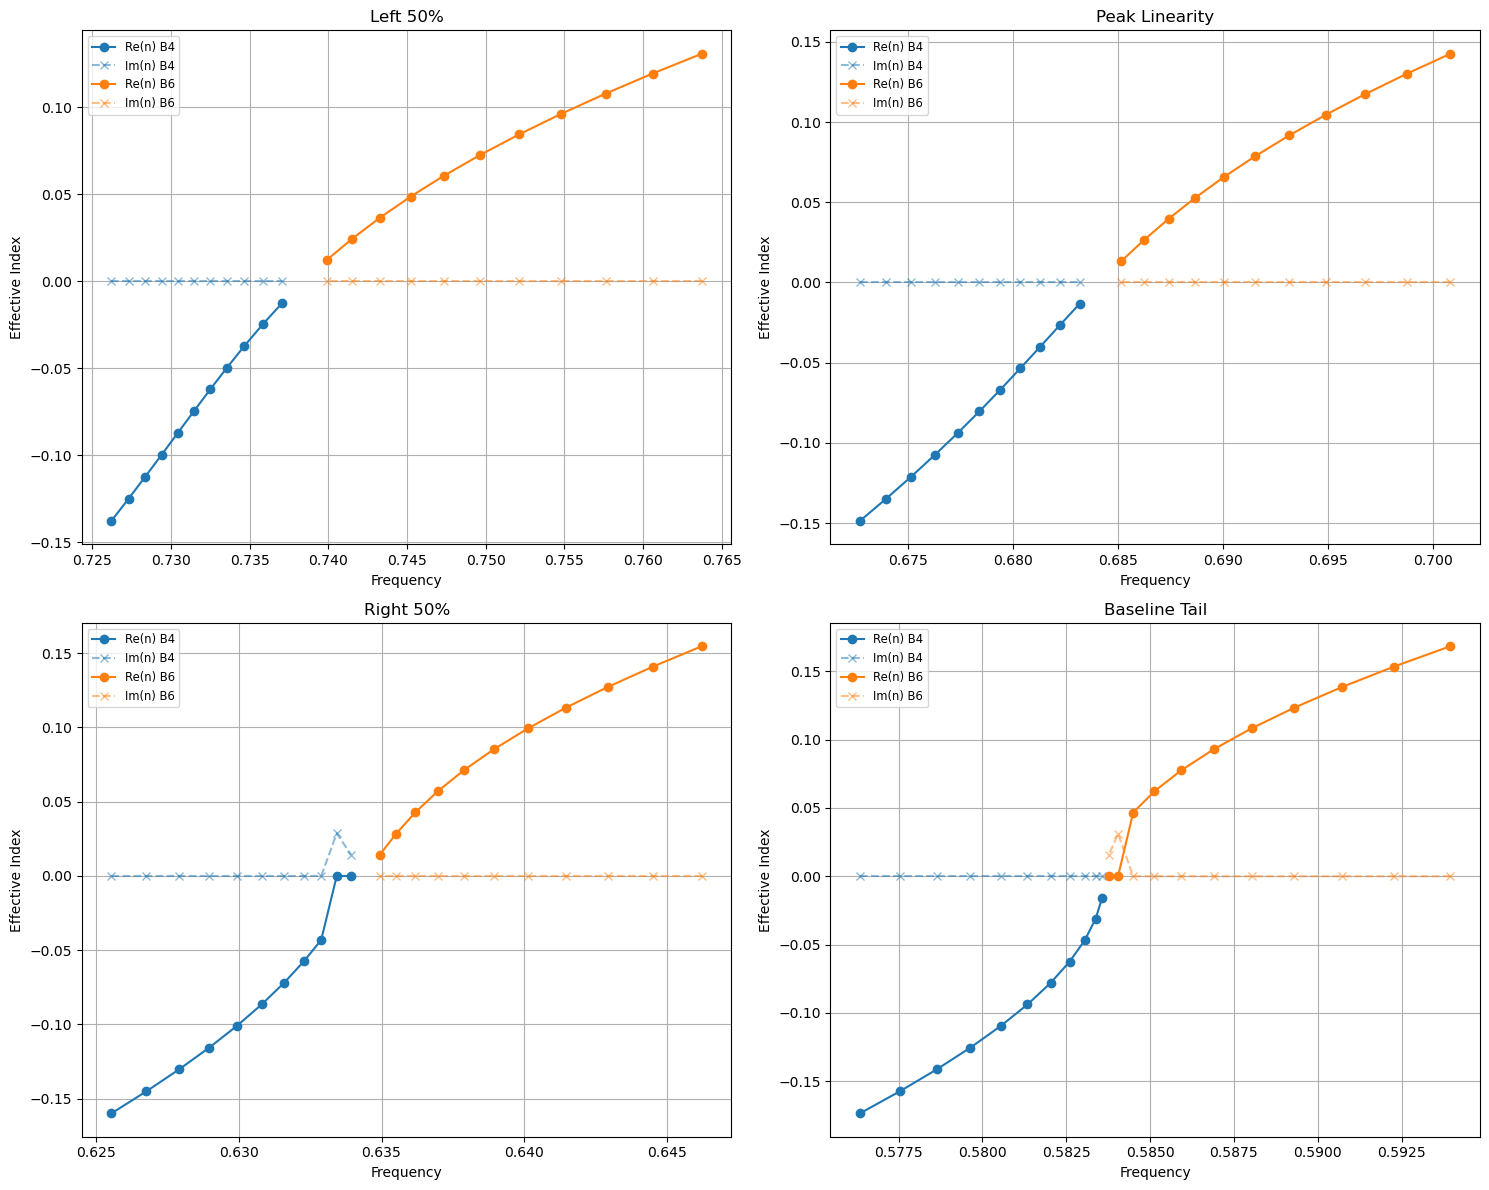

    k_index  band  frequency                 eps                  mu  \
24        1     6   0.593958  0.081203+0.000000j  0.349072+0.000000j   
25        2     6   0.592279  0.068266+0.000000j  0.345109+0.000000j   
26        3     6   0.590726  0.055812+0.000000j  0.343716+0.000000j   
27        4     6   0.589305  0.044824+0.000000j  0.339788+0.000000j   
28        5     6   0.588027  0.035257+0.000000j  0.332181+0.000000j   
29        6     6   0.586900  0.026732+0.000000j  0.323118+0.000000j   
30        7     6   0.585932  0.022297+0.000000j  0.269908+0.000000j   
31        8     6   0.585129  0.019261+0.000000j  0.200514+0.000000j   
32        9     6   0.584498  0.025065+0.000000j  0.086861+0.000000j   
33       10     6   0.584045  0.000000+0.200071j  0.000000+0.004844j   
34       11     6   0.583772  0.000000+0.182509j  0.000000+0.001329j   
35       12     6   0.583687  0.000000+0.000000j  0.000000+0.000000j   

             impedance               n_eff      kmag  
24  2.07

In [6]:
# Plotting and Jump Investigation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, (df, case) in enumerate(zip(result_dfs, cases)):
    ax = axes[idx]
    ax.set_title(f"{case['name']}")
    
    # Plot multiple bands to see upper/lower branches (e.g., 4, 5, 6)
    bands_to_plot = [4, 6]
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    
    for b_idx, color in zip(bands_to_plot, colors):
        df_band = df[df['band'] == b_idx]
        if not df_band.empty:
            ax.plot(df_band['frequency'], df_band['n_eff'].apply(lambda x: x.real), 'o-', color=color, label=f'Re(n) B{b_idx}')
            ax.plot(df_band['frequency'], df_band['n_eff'].apply(lambda x: x.imag), 'x--', color=color, alpha=0.5, label=f'Im(n) B{b_idx}')
    
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Effective Index")
    ax.legend(fontsize='small')
    ax.grid(True)

plt.tight_layout()
plt.show()
print(df_band)

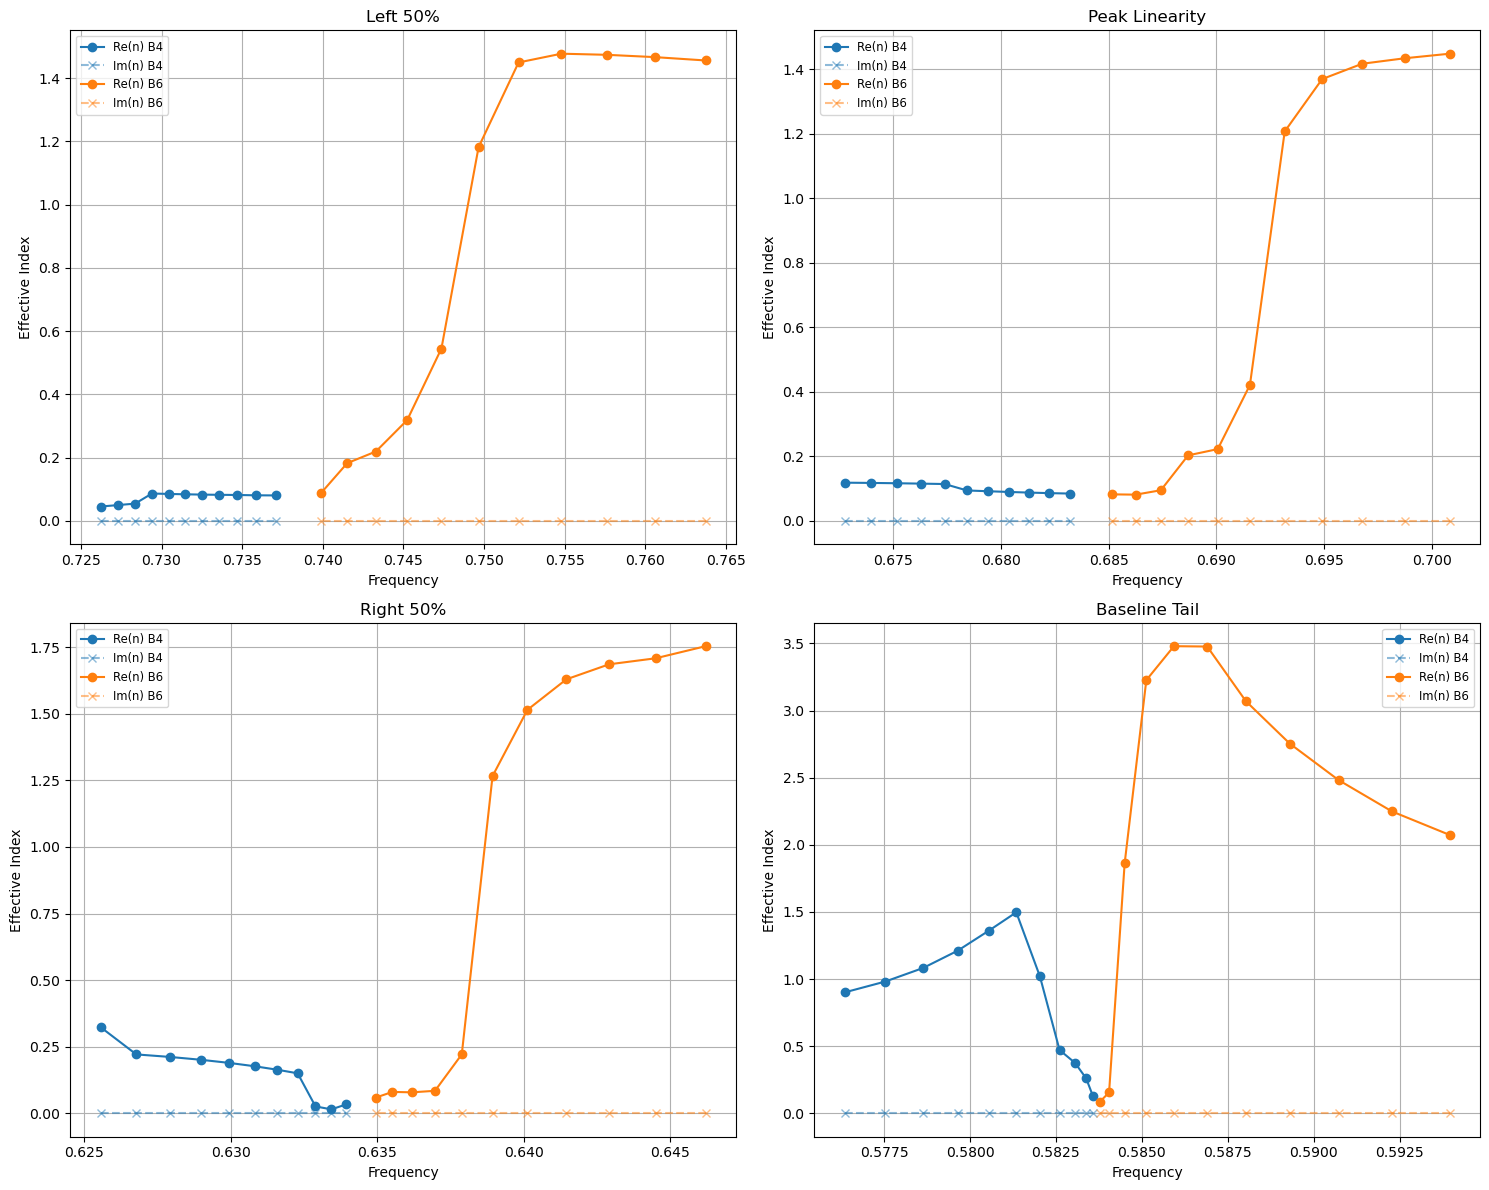

    k_index  band  frequency                 eps                  mu  \
24        1     6   0.593958  0.081203+0.000000j  0.349072+0.000000j   
25        2     6   0.592279  0.068266+0.000000j  0.345109+0.000000j   
26        3     6   0.590726  0.055812+0.000000j  0.343716+0.000000j   
27        4     6   0.589305  0.044824+0.000000j  0.339788+0.000000j   
28        5     6   0.588027  0.035257+0.000000j  0.332181+0.000000j   
29        6     6   0.586900  0.026732+0.000000j  0.323118+0.000000j   
30        7     6   0.585932  0.022297+0.000000j  0.269908+0.000000j   
31        8     6   0.585129  0.019261+0.000000j  0.200514+0.000000j   
32        9     6   0.584498  0.025065+0.000000j  0.086861+0.000000j   
33       10     6   0.584045  0.000000+0.200071j  0.000000+0.004844j   
34       11     6   0.583772  0.000000+0.182509j  0.000000+0.001329j   
35       12     6   0.583687  0.000000+0.000000j  0.000000+0.000000j   

             impedance               n_eff      kmag  
24  2.07

In [7]:
# Plotting and Jump Investigation
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, (df, case) in enumerate(zip(result_dfs, cases)):
    ax = axes[idx]
    ax.set_title(f"{case['name']}")
    
    # Plot multiple bands to see upper/lower branches (e.g., 4, 5, 6)
    bands_to_plot = [4, 6]
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    
    for b_idx, color in zip(bands_to_plot, colors):
        df_band = df[df['band'] == b_idx]
        if not df_band.empty:
            ax.plot(df_band['frequency'], df_band['impedance'].apply(lambda x: x.real), 'o-', color=color, label=f'Re(n) B{b_idx}')
            ax.plot(df_band['frequency'], df_band['impedance'].apply(lambda x: x.imag), 'x--', color=color, alpha=0.5, label=f'Im(n) B{b_idx}')
    
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Effective Index")
    ax.legend(fontsize='small')
    ax.grid(True)

plt.tight_layout()
plt.show()
print(df_band)